In [1]:
# Load the results for the first 5 weeks and import library needed
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation


gap = pd.read_csv("WeeklyGapSkills_W5.csv")
match = pd.read_csv("WeeklyMatchedSkills_W5.csv")
demand = pd.read_csv("WeeklyTopSkillCounts_W5.csv")

# function to clean week labels
def clean_week(df):
    df["Week"] = (
        df["Week"]
        .astype(str)
        .str.strip()
        .str.replace(r"-[vV]\d+$", "", regex=True)  # remove -v1 or -V1
    )
    return df

gap = clean_week(gap)
match = clean_week(match)
demand = clean_week(demand)

/Users/linyu/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
week_order = sorted(demand["Week"].unique())
for df in [gap, match, demand]:
    df["Week"] = pd.Categorical(df["Week"], categories=week_order, ordered=True)

## Most demanded skills to be a DS in the market

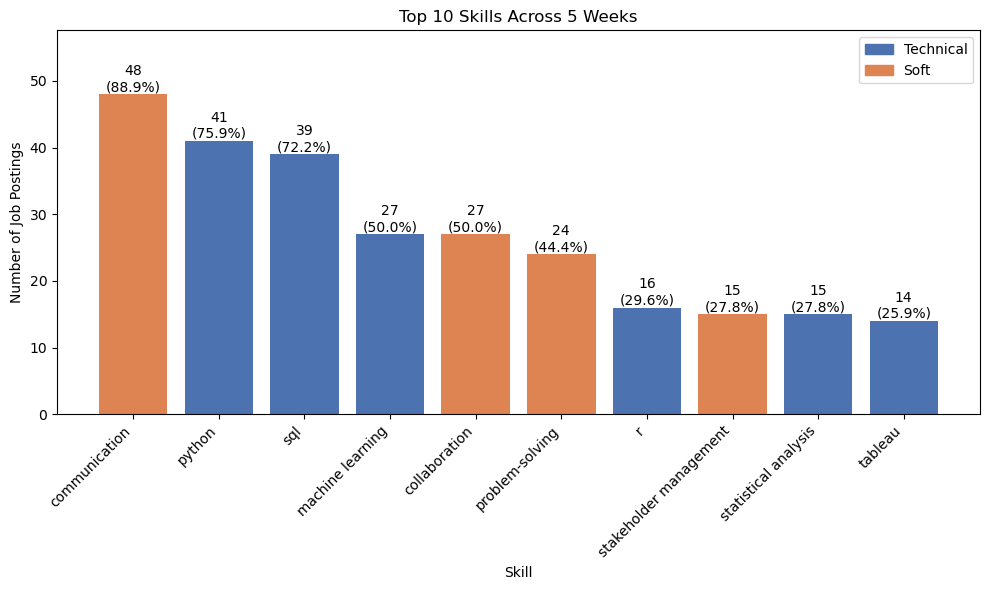

In [3]:
total_jobs = 54

top_demand = (
    demand.groupby(["Skill", "category"], as_index=False)["job_count"]
    .sum()
    .sort_values("job_count", ascending=False)
    .head(10)
)

# assign colors based on category
colors = top_demand["category"].map({
    "technical": "#4C72B0",
    "soft": "#DD8452"
})

plt.figure(figsize=(10, 6))

bars = plt.bar(top_demand["Skill"], top_demand["job_count"], color=colors)

plt.title("Top 10 Skills Across 5 Weeks")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")

# add counts + job percentage
for bar in bars:
    height = bar.get_height()
    pct = height / total_jobs * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}\n({pct:.1f}%)",
        ha="center",
        va="bottom"
    )

# add legend manually
import matplotlib.patches as mpatches
tech_patch = mpatches.Patch(color="#4C72B0", label="Technical")
soft_patch = mpatches.Patch(color="#DD8452", label="Soft")

plt.legend(handles=[tech_patch, soft_patch])

plt.ylim(0, top_demand["job_count"].max() * 1.2)

plt.tight_layout()
plt.show()

Findings:Communication is the most important skills mentioned across the job description. But how can companies evaluate in the resume process? 

## Tech vs. Soft skills Demand

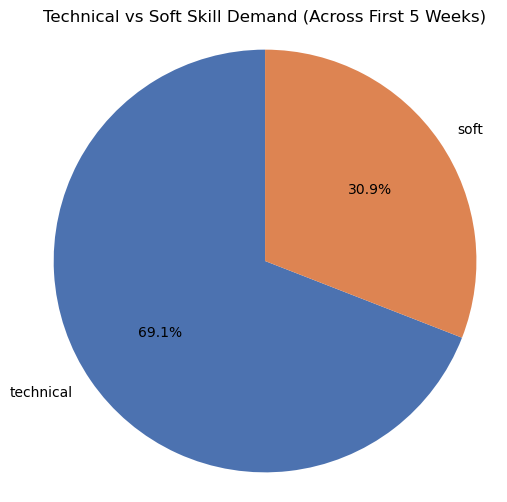

In [4]:
# Sum skill mentions by category across all weeks
category_counts = (
    demand.groupby("category")["job_count"]
    .sum()
)

# ensure consistent order
category_counts = category_counts.reindex(["technical", "soft"])

colors = ["#4C72B0", "#DD8452"]  # blue for technical, orange for soft

plt.figure(figsize=(6,6))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title("Technical vs Soft Skill Demand (Across First 5 Weeks)")

plt.axis('equal')  # keeps pie circular

plt.show()

### overall balance of skill types:
Aligns with my goal ---> technical focused but with a great amount of time to collaborate and improve my soft skills

In [5]:
soft_subset = demand[(demand["Week"] == "2026-W5-v1") & (demand["category"] == "soft")]


In [6]:
total_mentions = soft_subset["job_count"].sum()
print("Total mentions:", total_mentions)

Total mentions: 0


In [7]:
num_skills = soft_subset["Skill"].nunique()
print("Number of soft skills:", num_skills)

Number of soft skills: 0


In [8]:
tech_subset= demand[(demand["Week"] == "2026-W5-v1") & (demand["category"] == "technical")]
total_mentions = tech_subset["job_count"].sum()
print("Total mentions:", total_mentions)
num_skills = tech_subset["Skill"].nunique()
print("Number of tech skills:", num_skills)

Total mentions: 0
Number of tech skills: 0


## Weekly Demand Comparison

/var/folders/t2/7mtp11ks3nnd0l6dwsngdl680000gn/T/ipykernel_13974/4078221342.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demand.groupby(["Week", "category"])["job_count"]


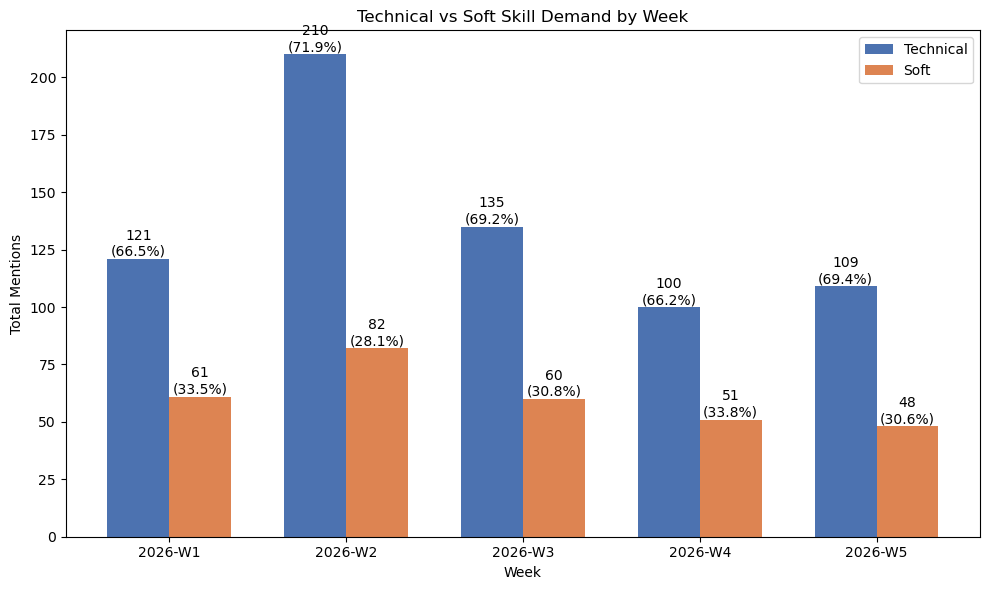

In [9]:
# Aggregate weekly counts
weekly_category = (
    demand.groupby(["Week", "category"])["job_count"]
    .sum()
    .unstack(fill_value=0)
)

weekly_category = weekly_category.sort_index()

weeks = weekly_category.index
technical = weekly_category["technical"]
soft = weekly_category["soft"]

# calculate percentages
totals = technical + soft
technical_pct = technical / totals * 100
soft_pct = soft / totals * 100

x = np.arange(len(weeks))
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, technical, width, label="Technical", color="#4C72B0")
bars2 = plt.bar(x + width/2, soft, width, label="Soft", color="#DD8452")

plt.xlabel("Week")
plt.ylabel("Total Mentions")
plt.title("Technical vs Soft Skill Demand by Week")
plt.xticks(x, weeks)
plt.legend()

# add labels with counts + percentages
for i, bar in enumerate(bars1):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}\n({technical_pct.iloc[i]:.1f}%)",
        ha='center',
        va='bottom'
    )

for i, bar in enumerate(bars2):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}\n({soft_pct.iloc[i]:.1f}%)",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Observations: Across all five weeks, technical skills consistently dominate demand, though soft skills remain present in every week, indicating their steady importance.

In [10]:
pivot = demand.pivot_table(
    index="Week",
    columns="Skill",
    values="job_count",
    aggfunc="sum",
    fill_value=0
)
week_order = sorted(
    pivot.index,
    key=lambda x: int(''.join(filter(str.isdigit, x)))
)

pivot = pivot.reindex(week_order)
print(pivot)

Skill    a/b testing  adaptability  additive modeling  adobe analytics  \
Week                                                                     
2026-W1            0             1                  0                0   
2026-W2            1             3                  1                0   
2026-W3            3             1                  0                0   
2026-W4            0             0                  0                0   
2026-W5            3             3                  0                1   

Skill    advanced analytics  agentic workflows  agile methodology  \
Week                                                                
2026-W1                   1                  0                  0   
2026-W2                   0                  0                  1   
2026-W3                   0                  1                  0   
2026-W4                   0                  0                  0   
2026-W5                   0                  0                  0  

/var/folders/t2/7mtp11ks3nnd0l6dwsngdl680000gn/T/ipykernel_13974/271339627.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = demand.pivot_table(


In [11]:
import bar_chart_race as bcr

# hold each week for ~2 seconds
pause_frames = 20          # 20 frames
frame_length = 100         # 100 ms per frame
# 20 * 100 ms = 2000 ms = 2 seconds

pivot_pause = pivot.loc[pivot.index.repeat(pause_frames)]

bcr.bar_chart_race(
    df=pivot_pause,
    filename="weekly_skill_demand.gif",
    n_bars=10,
    steps_per_period=1,
    period_length=frame_length,
    title="Top 10 Weekly Skill Demand for Data Scientist Roles",
    figsize=(8, 5),
    bar_label_size=10,
    tick_label_size=10,
    period_label={"x": 0.95, "y": 0.15, "ha": "right", "va": "center"},
    cmap="tab10",
    filter_column_colors=True
)

/Users/linyu/opt/anaconda3/lib/python3.9/site-packages/bar_chart_race/_make_chart.py:889: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_values.iloc[:, 0] = df_values.iloc[:, 0].fillna(method='ffill')
/Users/linyu/opt/anaconda3/lib/python3.9/site-packages/bar_chart_race/_make_chart.py:284: UserWarning: Glyph 127 () missing from current font.
  fig.canvas.print_figure(io.BytesIO())
/Users/linyu/opt/anaconda3/lib/python3.9/site-packages/bar_chart_race/_make_chart.py:284: UserWarning: Glyph 128 (\x80) missing from current font.
  fig.canvas.print_figure(io.BytesIO())
/Users/linyu/opt/anaconda3/lib/python3.9/site-packages/bar_chart_race/_make_chart.py:284: UserWarning: Glyph 129 (\x81) missing from current font.
  fig.canvas.print_figure(io.BytesIO())
/Users/linyu/opt/anaconda3/lib/python3.9/site-packages/bar_chart_race/_make_chart.py:284: UserWarning: Glyph 130 (\x82) missing from current font.
  f

In [12]:
top5_skills = top_demand["Skill"].head(5).tolist()

trend = (
    demand[demand["Skill"].isin(top5_skills)]
    .pivot_table(index="Week", columns="Skill", values="job_count", aggfunc="sum", fill_value=0)
)

print(trend)

Skill    collaboration  communication  machine learning  python  sql
Week                                                                
2026-W1              7              9                 5       7    9
2026-W2              8             13                 9      12    7
2026-W3              5             10                 5       8    9
2026-W4              4              7                 6       8    5
2026-W5              3              9                 2       6    9


/var/folders/t2/7mtp11ks3nnd0l6dwsngdl680000gn/T/ipykernel_13974/482967410.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  demand[demand["Skill"].isin(top5_skills)]


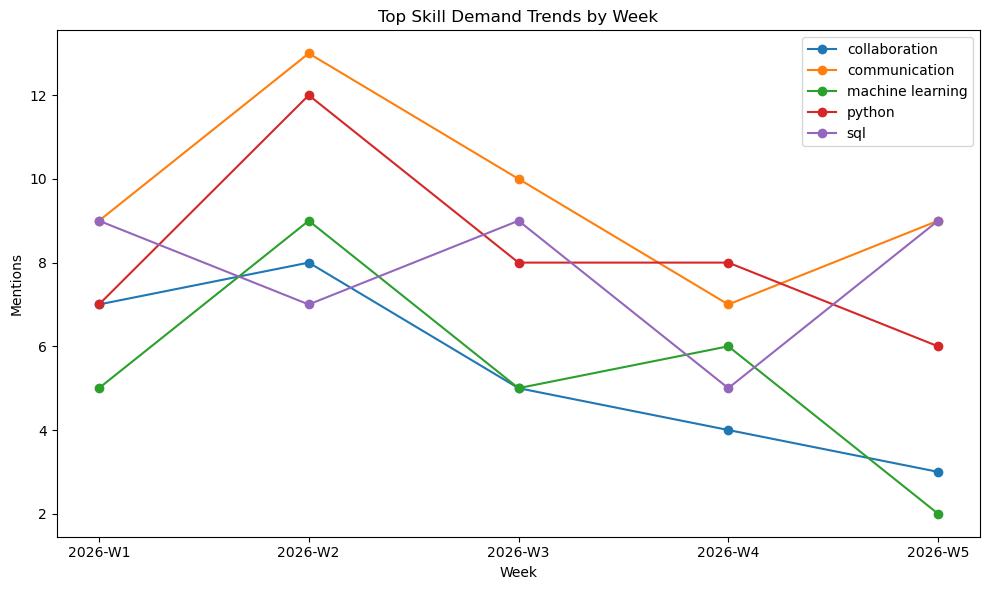

In [13]:
plt.figure(figsize=(10, 6))
for skill in trend.columns:
    plt.plot(trend.index.astype(str), trend[skill], marker="o", label=skill)

plt.title("Top Skill Demand Trends by Week")
plt.xlabel("Week")
plt.ylabel("Mentions")
plt.legend()
plt.tight_layout()
plt.show()

## Is current resume good enough compared to job description I am interested in?

Coverage ratios --> Quantifies how well your resume matches market demand

In [14]:
# total matched mentions per week
match_week = match.groupby("Week", as_index=False)["job_count"].sum()
match_week = match_week.rename(columns={"job_count": "matched"})

# total gap mentions per week
gap_week = gap.groupby("Week", as_index=False)["job_count"].sum()
gap_week = gap_week.rename(columns={"job_count": "gap"})

# merge tables
coverage_week = pd.merge(match_week, gap_week, on="Week")

# total mentions
coverage_week["total"] = coverage_week["matched"] + coverage_week["gap"]

# percentages
coverage_week["matched_pct"] = coverage_week["matched"] / coverage_week["total"] * 100
coverage_week["gap_pct"] = coverage_week["gap"] / coverage_week["total"] * 100

print(coverage_week)

      Week  matched  gap  total  matched_pct    gap_pct
0  2026-W1       80    6     86    93.023256   6.976744
1  2026-W2       93   12    105    88.571429  11.428571
2  2026-W3       70    9     79    88.607595  11.392405
3  2026-W4       63    6     69    91.304348   8.695652
4  2026-W5       62   12     74    83.783784  16.216216


/var/folders/t2/7mtp11ks3nnd0l6dwsngdl680000gn/T/ipykernel_13974/2916698922.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  match_week = match.groupby("Week", as_index=False)["job_count"].sum()
/var/folders/t2/7mtp11ks3nnd0l6dwsngdl680000gn/T/ipykernel_13974/2916698922.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gap_week = gap.groupby("Week", as_index=False)["job_count"].sum()


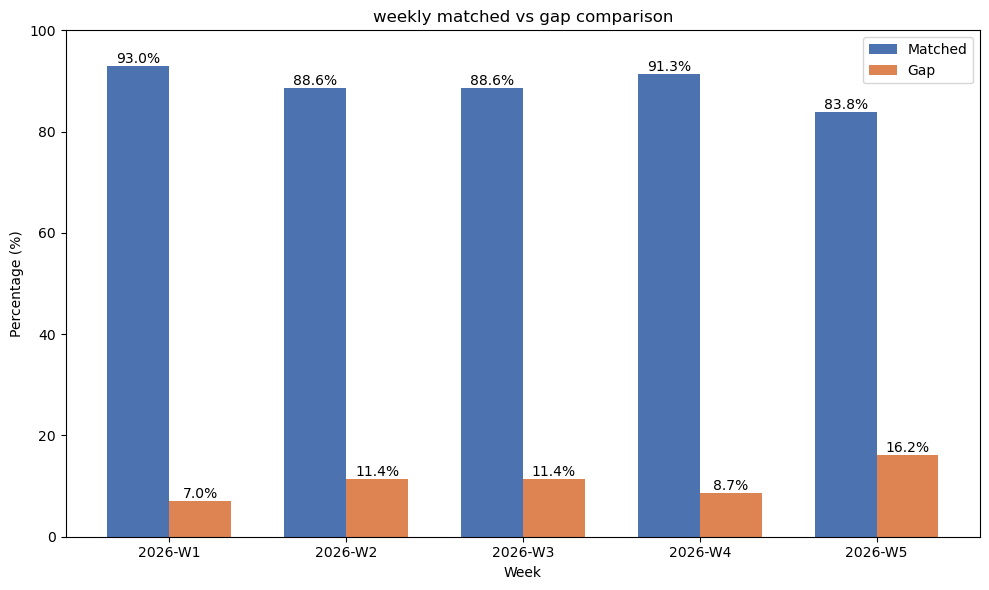

In [15]:
weeks = coverage_week["Week"]
x = np.arange(len(weeks))
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, coverage_week["matched_pct"], width,
                label="Matched", color="#4C72B0")

bars2 = plt.bar(x + width/2, coverage_week["gap_pct"], width,
                label="Gap", color="#DD8452")

plt.xticks(x, weeks)
plt.ylabel("Percentage (%)")
plt.xlabel("Week")
plt.title("weekly matched vs gap comparison")
plt.legend()

# add labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, height,
             f"{height:.1f}%", ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, height,
             f"{height:.1f}%", ha='center', va='bottom')

plt.ylim(0,100)
plt.tight_layout()
plt.show()

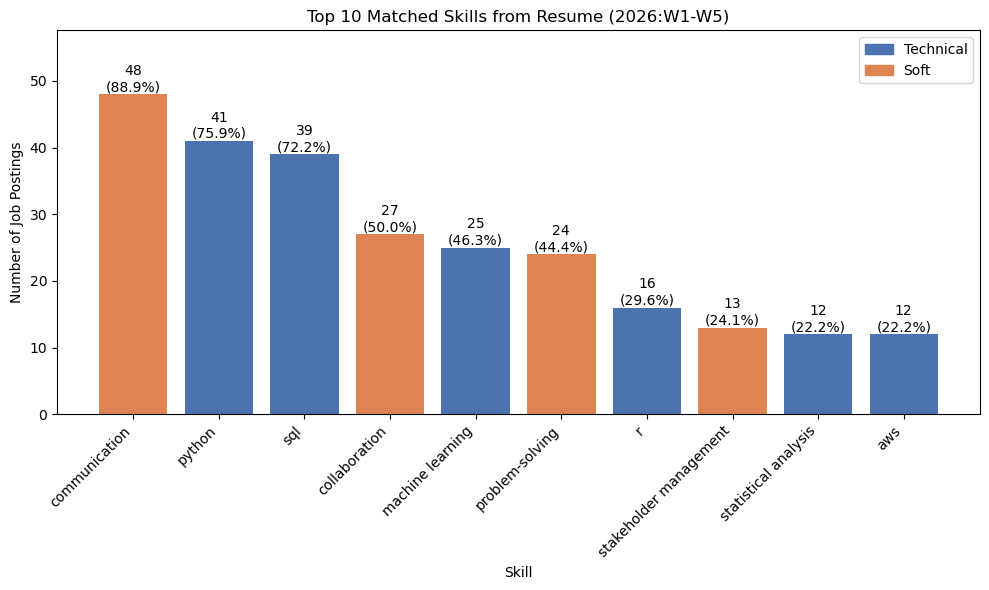

In [17]:
total_jobs = 54

top_match = (
    match.groupby(["skill", "category"], as_index=False)["job_count"]
    .sum()
    .sort_values("job_count", ascending=False)
    .head(10)
)

# color mapping
colors = top_match["category"].map({
    "technical": "#4C72B0",
    "soft": "#DD8452"
})

plt.figure(figsize=(10, 6))

bars = plt.bar(top_match["skill"], top_match["job_count"], color=colors)

plt.title("Top 10 Matched Skills from Resume (2026:W1-W5)")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")

# add count + percentage labels
for bar in bars:
    height = bar.get_height()
    pct = height / total_jobs * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}\n({pct:.1f}%)",
        ha="center",
        va="bottom"
    )

# legend
import matplotlib.patches as mpatches
tech_patch = mpatches.Patch(color="#4C72B0", label="Technical")
soft_patch = mpatches.Patch(color="#DD8452", label="Soft")

plt.legend(handles=[tech_patch, soft_patch])

plt.ylim(0, top_match["job_count"].max() * 1.2)

plt.tight_layout()
plt.show()

## Top Missing Skills in My Resume 

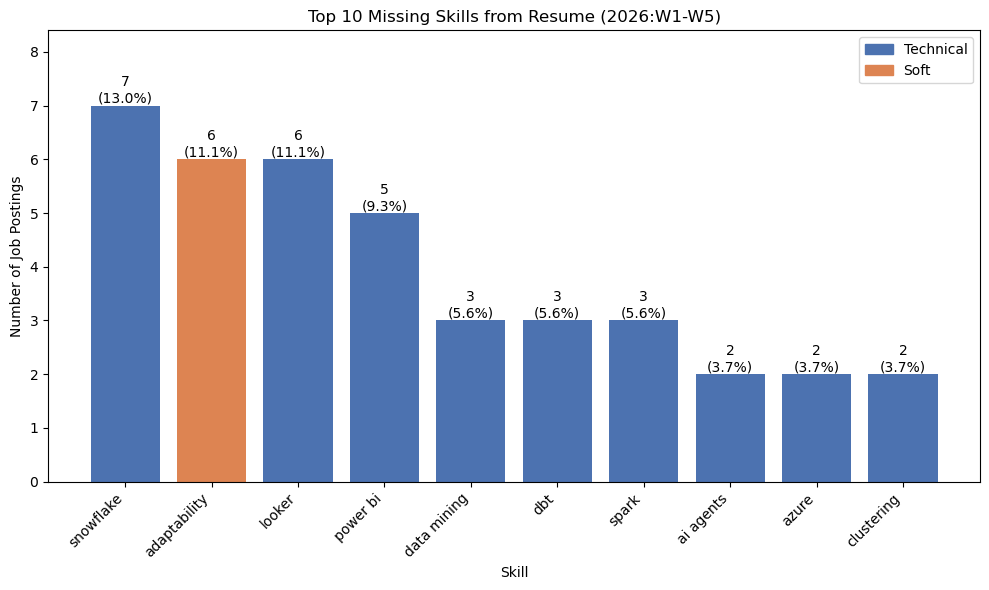

In [16]:
total_jobs = 54

top_gap = (
    gap.groupby(["skill", "category"], as_index=False)["job_count"]
    .sum()
    .sort_values("job_count", ascending=False)
    .head(10)
)

# color mapping
colors = top_gap["category"].map({
    "technical": "#4C72B0",
    "soft": "#DD8452"
})

plt.figure(figsize=(10, 6))

bars = plt.bar(top_gap["skill"], top_gap["job_count"], color=colors)

plt.title("Top 10 Missing Skills from Resume (2026:W1-W5)")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")

# add count + percentage labels
for bar in bars:
    height = bar.get_height()
    pct = height / total_jobs * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}\n({pct:.1f}%)",
        ha="center",
        va="bottom"
    )

# legend
import matplotlib.patches as mpatches
tech_patch = mpatches.Patch(color="#4C72B0", label="Technical")
soft_patch = mpatches.Patch(color="#DD8452", label="Soft")

plt.legend(handles=[tech_patch, soft_patch])

plt.ylim(0, top_gap["job_count"].max() * 1.2)

plt.tight_layout()
plt.show()